In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import io

/Users/tinazhong/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Load clean dataset
df = pd.read_csv("clean_diabetes.csv")

y = df["readmit_30"]
X = df.drop(columns=["readmit_30"])

In [3]:
print(df.columns)

Index(['patient_nbr', 'age', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'number_diagnoses', 'change',
       'diabetesMed', 'metformin_used', 'repaglinide_used', 'nateglinide_used',
       'chlorpropamide_used', 'glimepiride_used', 'acetohexamide_used',
       'glipizide_used', 'glyburide_used', 'tolbutamide_used',
       'pioglitazone_used', 'rosiglitazone_used', 'acarbose_used',
       'miglitol_used', 'troglitazone_used', 'tolazamide_used', 'examide_used',
       'citoglipton_used', 'insulin_used', 'glyburide-metformin_used',
       'glipizide-metformin_used', 'glimepiride-pioglitazone_used',
       'metformin-rosiglitazone_used', 'metformin-pioglitazone_used',
       'readmit_30', 'race_Asian', 'race_Caucasian', 'race_Hispanic',
       'race_Other', 'race_Unknown', 'gender_Male', 'gender_Unknown',
       'admission_type_id_2', 'admission_type_id_3', 'admission_type_id_4',


In [4]:
# Split by patient so encounters from the same person stay in one set.
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.3,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=X["patient_nbr"])
)

X_train = X.iloc[train_idx].drop(columns=["patient_nbr"])
X_test = X.iloc[test_idx].drop(columns=["patient_nbr"])
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [5]:
# Handle dataset imbalanced with SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts(normalize=True))
print("After:", y_train_res.value_counts(normalize=True))

Before: readmit_30
0    0.886952
1    0.113048
Name: proportion, dtype: float64
After: readmit_30
0    0.5
1    0.5
Name: proportion, dtype: float64


In [6]:
# Scale the predictors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Train logistic regression model
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1,
    solver="lbfgs"
)

log_reg.fit(X_train_scaled, y_train_res)

# Predictions on (unresampled) test set
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred_log = log_reg.predict(X_test_scaled)

auc_log = roc_auc_score(y_test, y_prob_log)
acc_log = accuracy_score(y_test, y_pred_log)

print("=== Logistic Regression ===")
print("AUC:", round(auc_log, 3))
print("Accuracy:", round(acc_log, 3))
print(classification_report(y_test, y_pred_log, digits=3))

/Users/tinazhong/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


=== Logistic Regression ===
AUC: 0.571
Accuracy: 0.766
              precision    recall  f1-score   support

           0      0.897     0.831     0.863     26720
           1      0.165     0.258     0.201      3450

    accuracy                          0.766     30170
   macro avg      0.531     0.545     0.532     30170
weighted avg      0.813     0.766     0.787     30170



In [8]:
# Training RF model
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_res, y_train_res)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

auc_rf = roc_auc_score(y_test, y_prob_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print("AUC:", round(auc_rf, 3))
print("Accuracy:", round(acc_rf, 3))
print(classification_report(y_test, y_pred_rf, digits=3))

=== Random Forest ===
AUC: 0.604
Accuracy: 0.821
              precision    recall  f1-score   support

           0      0.893     0.907     0.900     26720
           1      0.176     0.154     0.164      3450

    accuracy                          0.821     30170
   macro avg      0.534     0.530     0.532     30170
weighted avg      0.811     0.821     0.816     30170



In [9]:
# Train XGBoost model
# ratio of negatives to positives in training set
scale = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.7,
    reg_alpha=0.2,
    reg_lambda=1.0,
    min_child_weight=3,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb.predict(X_test)

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("=== XGBoost ===")
print("AUC:", round(auc_xgb, 3))
print("Accuracy:", round(acc_xgb, 3))
print(classification_report(y_test, y_pred_xgb, digits=3))

=== XGBoost ===
AUC: 0.665
Accuracy: 0.664
              precision    recall  f1-score   support

           0      0.923     0.678     0.781     26720
           1      0.184     0.561     0.277      3450

    accuracy                          0.664     30170
   macro avg      0.553     0.619     0.529     30170
weighted avg      0.838     0.664     0.724     30170



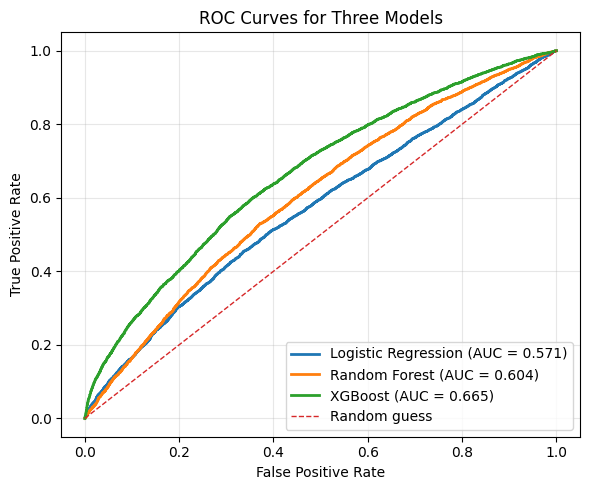

In [10]:
# Print ROC curve
# Put everything in a dict so we can loop
roc_data = {
    "Logistic Regression": y_prob_log,
    "Random Forest":       y_prob_rf,
    "XGBoost":             y_prob_xgb,
}



plt.figure(figsize=(6, 5))

for model_name, y_prob in roc_data.items():
    # Compute ROC points
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    # Plot ROC curve for this model
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})", linewidth=2)

# Diagonal line = random classifier
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Three Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Print confusion matrix
def print_confusion_matrix(y_true, y_pred, model_name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"=== {model_name} ===")
    print(f"TN: {tn}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"TP: {tp}")
    print()

# Logistic Regression
print_confusion_matrix(y_test, y_pred_log, "Logistic Regression")

# Random Forest
print_confusion_matrix(y_test, y_pred_rf, "Random Forest")

# XGBoost
print_confusion_matrix(y_test, y_pred_xgb, "XGBoost")


=== Logistic Regression ===
TN: 22212
FP: 4508
FN: 2559
TP: 891

=== Random Forest ===
TN: 24237
FP: 2483
FN: 2919
TP: 531

=== XGBoost ===
TN: 18104
FP: 8616
FN: 1513
TP: 1937



In [12]:
# Print sensitivity and specificity for each model

def print_sens_spec(y_true, y_pred, model_name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    sensitivity = tp / (tp + fn)      # recall for class 1
    specificity = tn / (tn + fp)      # recall for class 0

    print(f"=== {model_name} ===")
    print(f"Sensitivity (Recall 1): {sensitivity:.3f}")
    print(f"Specificity (Recall 0): {specificity:.3f}")
    print()

# Logistic Regression
print_sens_spec(y_test, y_pred_log, "Logistic Regression")

# Random Forest
print_sens_spec(y_test, y_pred_rf, "Random Forest")

# XGBoost
print_sens_spec(y_test, y_pred_xgb, "XGBoost")


=== Logistic Regression ===
Sensitivity (Recall 1): 0.258
Specificity (Recall 0): 0.831

=== Random Forest ===
Sensitivity (Recall 1): 0.154
Specificity (Recall 0): 0.907

=== XGBoost ===
Sensitivity (Recall 1): 0.561
Specificity (Recall 0): 0.678



### Replace abstract ids to readable descriptions in admission_type, discharge_disposition, and admission_source

In [13]:
# Final Column Mapping Dictionary
column_mapping = {
    "admission_type_id_2": "Admission Type 2: Urgent",
    "admission_type_id_3": "Admission Type 3: Elective",
    "admission_type_id_4": "Admission Type 4: Newborn",
    "admission_type_id_5": "Admission Type 5: Not Available",
    "admission_type_id_7": "Admission Type 7: Trauma Center",
    "admission_type_id_8": "Admission Type 8: Not Mapped",
    "discharge_disposition_id_2": "Discharge 2: Short term hospital",
    "discharge_disposition_id_3": "Discharge 3: Skilled Nursing Facility (SNF)",
    "discharge_disposition_id_4": "Discharge 4: Intermediate Care Facility (ICF)",
    "discharge_disposition_id_5": "Discharge 5: Inpatient care institution",
    "discharge_disposition_id_6": "Discharge 6: Home with home health service",
    "discharge_disposition_id_7": "Discharge 7: Left AMA (Against Medical Advice)",
    "discharge_disposition_id_8": "Discharge 8: Home under care of Home IV provider",
    "discharge_disposition_id_9": "Discharge 9: Admitted as inpatient",
    "discharge_disposition_id_10": "Discharge 10: Neonate to another hospital",
    "discharge_disposition_id_12": "Discharge 12: Still patient/return for outpatient",
    "discharge_disposition_id_13": "Discharge 13: Hospice / home",
    "discharge_disposition_id_14": "Discharge 14: Hospice / medical facility",
    "discharge_disposition_id_15": "Discharge 15: Within institution to Medicare approved swing bed",
    "discharge_disposition_id_16": "Discharge 16: Outpatient services (other inst)",
    "discharge_disposition_id_17": "Discharge 17: Outpatient services (this inst)",
    "discharge_disposition_id_22": "Discharge 22: Transfer to another rehab facility",
    "discharge_disposition_id_23": "Discharge 23: Long term care hospital",
    "discharge_disposition_id_24": "Discharge 24: Nursing facility (Medicaid)",
    "discharge_disposition_id_25": "Discharge 25: Not Mapped",
    "discharge_disposition_id_27": "Discharge 27: Federal health care facility",
    "discharge_disposition_id_28": "Discharge 28: Psychiatric hospital",
    "admission_source_id_2": "Admission Source 2: Clinic Referral",
    "admission_source_id_3": "Admission Source 3: HMO Referral",
    "admission_source_id_4": "Admission Source 4: Transfer from hospital",
    "admission_source_id_5": "Admission Source 5: Transfer from SNF",
    "admission_source_id_6": "Admission Source 6: Transfer from other facility",
    "admission_source_id_7": "Admission Source 7: Emergency Room",
    "admission_source_id_8": "Admission Source 8: Court/Law Enforcement",
    "admission_source_id_9": "Admission Source 9: Not Available",
    "admission_source_id_10": "Admission Source 10: Transfer from critical access hospital",
    "admission_source_id_11": "Admission Source 11: Normal Delivery",
    "admission_source_id_13": "Admission Source 13: Sick Baby",
    "admission_source_id_14": "Admission Source 14: Extramural Birth",
    "admission_source_id_20": "Admission Source 20: Not Mapped",
    "admission_source_id_22": "Admission Source 22: Transfer from hospital inpt (sep claim)",
    "admission_source_id_25": "Admission Source 25: Transfer from Ambulatory Surgery Center"
}

# Implementation code
df = df.rename(columns=column_mapping)

In [14]:
print(df.columns)

Index(['patient_nbr', 'age', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'number_diagnoses', 'change',
       'diabetesMed', 'metformin_used', 'repaglinide_used', 'nateglinide_used',
       'chlorpropamide_used', 'glimepiride_used', 'acetohexamide_used',
       'glipizide_used', 'glyburide_used', 'tolbutamide_used',
       'pioglitazone_used', 'rosiglitazone_used', 'acarbose_used',
       'miglitol_used', 'troglitazone_used', 'tolazamide_used', 'examide_used',
       'citoglipton_used', 'insulin_used', 'glyburide-metformin_used',
       'glipizide-metformin_used', 'glimepiride-pioglitazone_used',
       'metformin-rosiglitazone_used', 'metformin-pioglitazone_used',
       'readmit_30', 'race_Asian', 'race_Caucasian', 'race_Hispanic',
       'race_Other', 'race_Unknown', 'gender_Male', 'gender_Unknown',
       'Admission Type 2: Urgent', 'Admission Type 3: Elective',
       'Adm

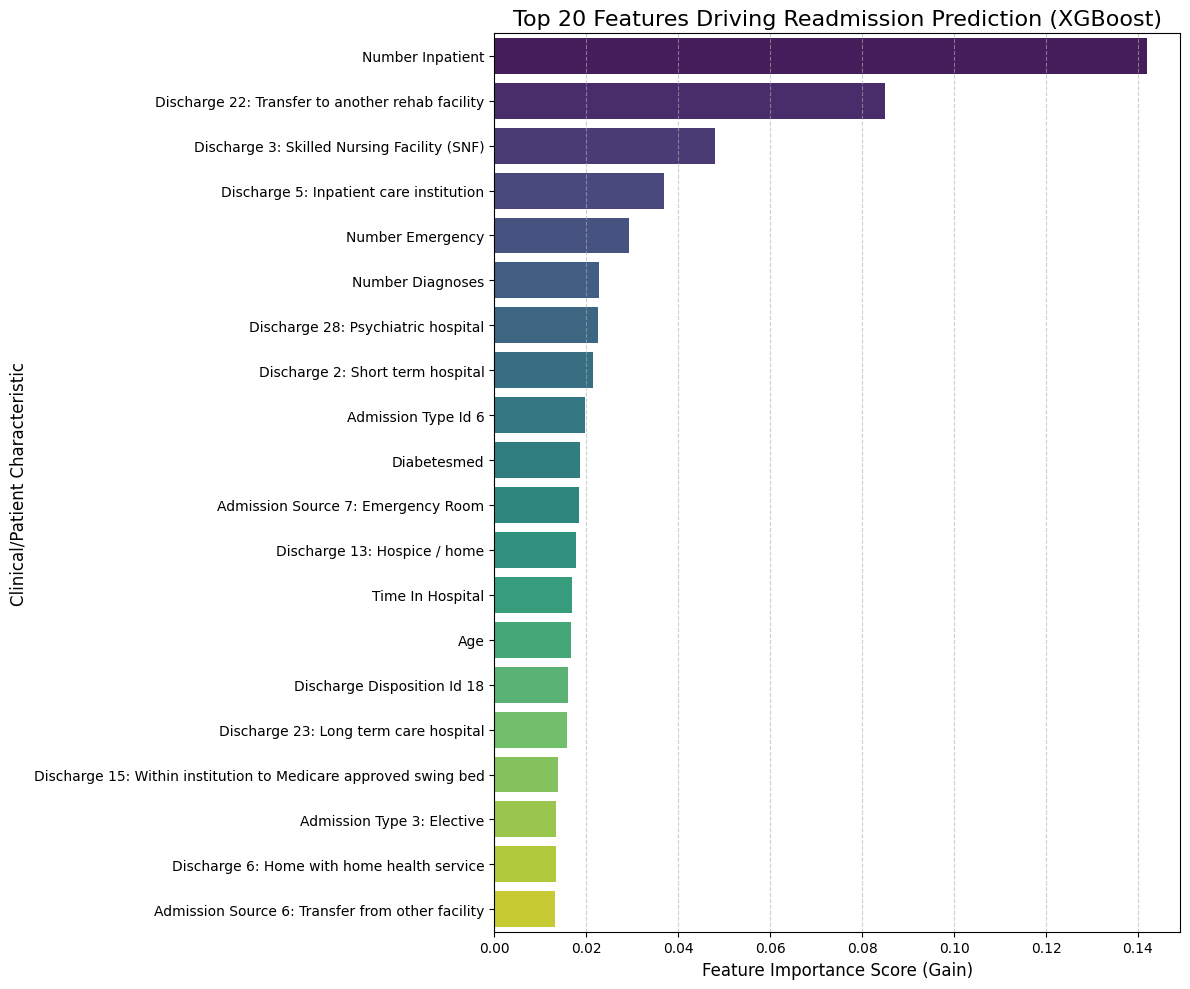


Top 15 Predictors (Descriptive):
                                 Feature_Display  Importance
                                Number Inpatient    0.142035
Discharge 22: Transfer to another rehab facility    0.084988
     Discharge 3: Skilled Nursing Facility (SNF)    0.048068
         Discharge 5: Inpatient care institution    0.037005
                                Number Emergency    0.029390
                                Number Diagnoses    0.022746
              Discharge 28: Psychiatric hospital    0.022606
                Discharge 2: Short term hospital    0.021397
                             Admission Type Id 6    0.019704
                                     Diabetesmed    0.018605
              Admission Source 7: Emergency Room    0.018455
                    Discharge 13: Hospice / home    0.017774
                                Time In Hospital    0.017021
                                             Age    0.016637
                     Discharge Disposition Id 18   

In [15]:
# Plot feature importance for XGBoost model
# Extract feature importances from the trained XGB model
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Create a display-friendly column using the map
# Use .get() to return a formatted version of the original name if it's not in the map
feature_importance['Feature_Display'] = feature_importance['Feature'].apply(
    lambda x: column_mapping.get(x, x.replace('_', ' ').title())
)

# Plot Top 20 Features using the Display Names
plt.figure(figsize=(12, 10))
sns.barplot(
    x='Importance', 
    y='Feature_Display', # Updated to use display names
    data=feature_importance.head(20), 
    palette='viridis'
)
plt.title('Top 20 Features Driving Readmission Prediction (XGBoost)', fontsize=16)
plt.xlabel('Feature Importance Score (Gain)', fontsize=12)
plt.ylabel('Clinical/Patient Characteristic', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Display the top 15 as text for easy report inclusion
print("\nTop 15 Predictors (Descriptive):")

# to_string looks clean and doesn't require the tabulate library
print(feature_importance[['Feature_Display', 'Importance']].head(15).to_string(index=False))

In [16]:
import joblib

# Save models
joblib.dump(log_reg, "logistic_model.pkl")
joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(xgb, "xgboost_model.pkl")

joblib.dump(scaler, "scaler.pkl")
#joblib.dump(sm, "smote.pkl")

print("Models saved!")


Models saved!
